In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline

from mnist_lipschitz.adversarial import strong_cnn_experiment
from mnist_lipschitz.adversarial import run_experiment
from mnist_lipschitz.adversarial import plots as adv_plots
from mnist_lipschitz.adversarial.run_experiment import most_and_least_sensitive_examples, FlattenedInputWrapper
from mnist_lipschitz.adversarial.strong_cnn_experiment import strong_cnn_head_layer_bound_check
from mnist_lipschitz.estimators import euclidean_distance_fn


# Adversarial Perturbation vs. Lipschitz Bound (StrongCNN)

## Motivation

`notebook_adversarial_lipschitz.ipynb` (sibling notebook) runs this same comparison for
`SmallCNN`: generate real FGSM/PGD adversarial examples against a trained checkpoint, and check
whether their achieved sensitivity ratio sits close to a TIGHT Lipschitz bound
(`L_full_estimated`, the network's own empirical Lipschitz constant) or the LOOSE per-layer
submultiplicative bound (`product_bound = L_extractor_estimated * L_head_exact`, Szegedy et al.
2014).

This notebook repeats that comparison for `StrongCNN` (`models.py`) -- the project's
higher-capacity, near-state-of-the-art baseline (BatchNorm, dropout, light augmentation, ~99.3%+
test-accuracy target) -- with two structural differences from the SmallCNN version, both handled
in the sibling module `strong_cnn_experiment.py` (not by modifying `models.py` or
`layer_decomposition.py`):

1. **`StrongCNN` has no `.extractor`/`.head` submodule split.** Its final classifier layer
   (`model.classifier[4]`) IS a plain `nn.Linear` with nothing nonlinear after it, so the same
   tight/loose bound comparison is still possible via an EXTERNALLY-constructed extractor/head
   split (`strong_cnn_extractor_fn` = `model.features` + `model.classifier[:4]`,
   `strong_cnn_head_module` = `model.classifier[4]`).
2. **`StrongCNN` has `BatchNorm1d`/`Dropout2d`/`Dropout` layers `SmallCNN` never had**, which
   makes `model.eval()` mode non-optional for every downstream computation (bound estimation AND
   attacks) to be well-defined -- `strong_cnn_experiment.py`'s functions RAISE `ValueError`
   rather than silently fixing this if the model is left in train mode; see that module's
   docstring.

**Scope: baseline only.** No CNN-width sweep (`StrongCNN`'s conv channels are hardcoded, not a
constructor parameter, unlike `SmallCNN`'s) and no multi-seed pilot (`seed_sweep.py`'s pattern,
also `SmallCNN`-specific) -- both deliberately out of scope here.

**`max_R_adv` is still a LOWER BOUND on the network's true worst-case sensitivity**, exactly as in
the SmallCNN notebook -- FGSM/PGD maximize cross-entropy loss, not `R_adv` directly. Results
throughout are "achieved under this attack," never "the" worst case.

**Weaker checkpoint-gating than the SmallCNN machinery**: `strong_cnn_experiment.py`'s central
correctness check (`tests/test_strong_cnn_experiment.py`) is a SELF-consistency check (does
`compute_strong_cnn_bounds` reduce to a from-scratch manual computation using the same closures),
not a check against an independently-existing reference the way `compute_bounds_with_distance_fn`
checks against `layer_decomposition_experiment` for SmallCNN -- no such reference exists for
StrongCNN, since `layer_decomposition.py` was deliberately never extended to it.


## Baseline checkpoint: train, then compare against both bounds

`strong_cnn_experiment.main()` trains ONE `StrongCNN` via `STRONG_CNN_CONFIG`'s exact recipe
(full 60k MNIST, 25 epochs, light rotation/translation augmentation, cosine-annealed learning
rate -- the SAME recipe `mnist_lipschitz.run_experiment.run_stronger_cnn_raw_mnist_experiment`
uses elsewhere in this project), then runs the full epsilon sweep and tight/loose bound
comparison against it. The checkpoint is cached to `results/strong_cnn_state_dict.pt` -- the
Mahalanobis section below reuses the SAME weights rather than retraining (training doesn't
depend on `distance_fn`, exactly as in the SmallCNN notebook's Euclidean/Mahalanobis reuse).


In [2]:
summary_df, sweep_results, strong_cnn_model = strong_cnn_experiment.main(
    distance_fn=euclidean_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict.pt (train_acc=0.9981  test_acc=0.9966)


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1033  L_extractor_est=4.2951  L_full_est=6.1481  looseness_ratio=1.4694


filter_correctly_classified: kept 0.9965 of the pool (1993/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=12.4839  max_R_adv=17.5427  pct_misclassified=0.2600


  epsilon=0.05  PGD   mean_R_adv=16.1468  max_R_adv=22.9244  pct_misclassified=0.6780


...

  epsilon=0.15  PGD   mean_R_adv=10.2094  max_R_adv=13.7791  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=4.9124  max_R_adv=6.7625  pct_misclassified=0.8500


  epsilon=0.2  PGD   mean_R_adv=9.1961  max_R_adv=12.1106  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=4.1236  max_R_adv=5.6587  pct_misclassified=0.9240


  epsilon=0.25  PGD   mean_R_adv=8.5493  max_R_adv=11.4623  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM   12.483935     12.737542  17.542705              0.260          6.148053       9.033935         2.853376                1.941867
    0.10   FGSM    8.170265      8.259075  11.429583              0.564          6.148053       9.033935         1.859057                1.265183
    0.15   FGSM    6.112639      6.106699   8.565498              0.764          6.148053       9.033935         1.393205                0.948147
    0.20   FGSM    4.912421      4.932108   6.762501              0.850          6.148053       9.033935         1.099942                0.748566
    0.25   FGSM    4.123622      4.140613   5.658686              0.924          6.148053       9.033935         0.920403                0.626381
    0.05    PGD   16.146833     16.2243

**What to look for**: same columns as the SmallCNN notebook's baseline table
(`mean_R_adv`/`median_R_adv`/`max_R_adv`, `pct_misclassified`, `L_full_estimated`,
`product_bound`, `ratio_to_L_full`, `ratio_to_product_bound`) -- see that notebook's own "What to
look for" cell for the full explanation of each column. A
`WARNING: max_R_adv > L_full_estimated` print (if any) means `L_full_estimated` under-sampled
(too few pairs/query points), not a real bound violation -- same caveat as always.


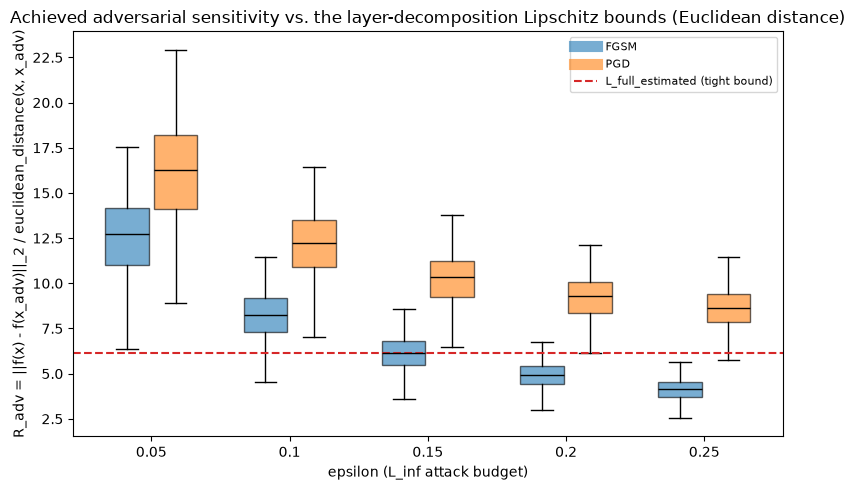

In [3]:
wrapped_strong_cnn = FlattenedInputWrapper(strong_cnn_model)

fig_R_adv_eucl = adv_plots.plot_R_adv_distribution(
    sweep_results, summary_df["L_full_estimated"].iloc[0], summary_df["product_bound"].iloc[0],
    metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_euclidean.png")


**FGSM, epsilon=0.05, Euclidean: R_adv split by attack outcome.** Same `R_adv` values as the
epsilon=0.05 FGSM box above, but as a histogram split by whether that specific example was
misclassified under the attack (red) or not (green) -- shows whether the attack's sensitivity
is concentrated among the examples it actually flips, or spread evenly regardless of outcome.


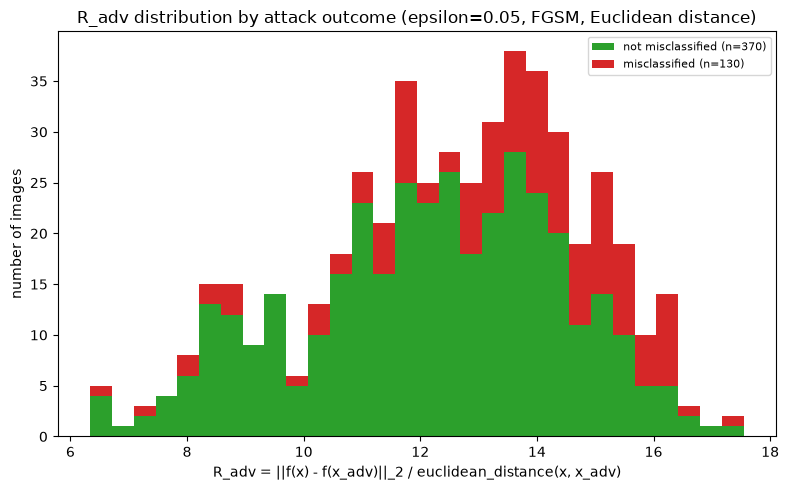

In [4]:
fig_R_adv_hist_fgsm_005 = adv_plots.plot_R_adv_histogram_by_outcome(
    sweep_results, epsilon=0.05, method="FGSM", metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_histogram_fgsm_eps0.05_euclidean.png")


**PGD, epsilon=0.05, Euclidean: R_adv split by attack outcome.** Same breakdown as the FGSM
histogram above, but for PGD at the same epsilon -- PGD's `pct_misclassified=0.678` at this
epsilon is far higher than FGSM's `0.260` (PGD's iterative, multi-restart search finds a much
larger fraction of adversarial directions FGSM's single gradient step misses), so expect the red
(misclassified) mass to dominate here.


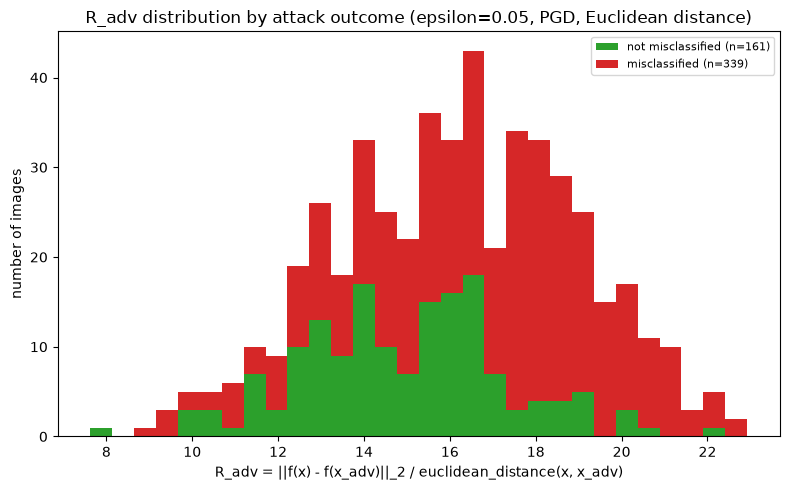

In [5]:
fig_R_adv_hist_pgd_005 = adv_plots.plot_R_adv_histogram_by_outcome(
    sweep_results, epsilon=0.05, method="PGD", metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_histogram_pgd_eps0.05_euclidean.png")


## Low-R_adv, still-misclassified examples (FGSM, epsilon=0.05, Euclidean)

Drilling into the histogram above: every example where FGSM at epsilon=0.05 achieved `R_adv < 10`
but still flipped the prediction -- the "cheap flips" where a below-median sensitivity ratio was
nonetheless enough to fool the model. For each: the clean and adversarial image, the model's full
logit vector (pre-softmax) on each, and the Euclidean pixel-space distance between the two images.


In [6]:
flagged_low_R_adv = run_experiment.find_examples_by_criteria(
    wrapped_strong_cnn, sweep_results, epsilon=0.05, method="FGSM",
    R_adv_max=10, misclassified_only=True)
print(f"Found {len(flagged_low_R_adv)} example(s) with R_adv < 10 that were misclassified "
      f"(FGSM, epsilon=0.05, Euclidean).")


Found 10 example(s) with R_adv < 10 that were misclassified (FGSM, epsilon=0.05, Euclidean).


--- example 0 (index=2) ---
R_adv=8.7468  pixel_distance (euclidean)=1.1182
logits_clean = [-6.2798 -3.5396 -4.248  -7.0108  2.5227 -5.4279 -8.7228 -1.7078 -2.1475
  7.5082]
logits_adv   = [-5.516  -3.8609 -2.3326 -4.3952  3.6585 -3.1345 -2.8074 -1.3572  0.7672
  1.6511]
--- example 1 (index=6) ---
R_adv=8.5284  pixel_distance (euclidean)=1.0588
logits_clean = [ 6.1017 -3.7596 -4.234  -5.5347 -4.7639 -2.1854  4.9486 -8.8159  0.6185
 -7.6906]
logits_adv   = [-0.4924 -4.4203 -2.6907 -4.4677 -0.0674 -0.2837  4.6219 -7.3045  2.3429
 -5.9401]
--- example 2 (index=31) ---
R_adv=8.6162  pixel_distance (euclidean)=1.0721
logits_clean = [ -5.9741  -1.1476  -3.0459  -6.8811   2.8108  -6.7633 -10.4555  -1.6463
  -1.8019   6.9251]
logits_adv   = [-5.5906 -1.8856 -1.8798 -6.7233  5.9948 -4.7068 -4.9877 -0.3789 -0.2309
  1.0161]
--- example 3 (index=43) ---
R_adv=6.7097  pixel_distance (euclidean)=1.0793
logits_clean = [  2.0128 -10.3557 -10.028   -4.0209 -10.3724   7.578    2.6387  -8.1401
   1.741

--- example 8 (index=424) ---
R_adv=7.8472  pixel_distance (euclidean)=1.0704
logits_clean = [-6.7833 -7.4393 -4.8527 -9.3209  4.1423 -4.8828 -4.0989 -2.6887 -3.7263
  8.5949]
logits_adv   = [-7.3452 -3.1297 -4.7406 -8.0067  5.4057 -1.9406 -1.8468 -1.9433 -2.8507
  2.8263]


--- example 9 (index=463) ---
R_adv=8.0045  pixel_distance (euclidean)=1.0234
logits_clean = [-6.2062 -6.5627 -5.1771 -8.6815  9.0519 -5.7757 -5.08   -4.3623 -2.2636
  3.7419]
logits_adv   = [-6.8349 -5.8451 -4.0001 -4.4319  4.3628 -1.3192 -3.4563 -4.8053 -0.9878
  4.4109]


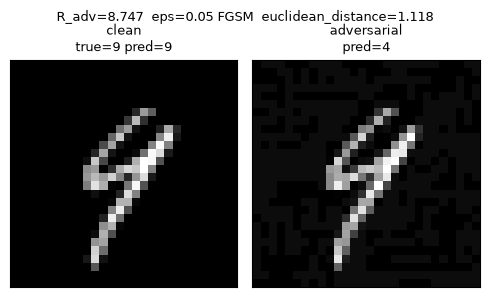

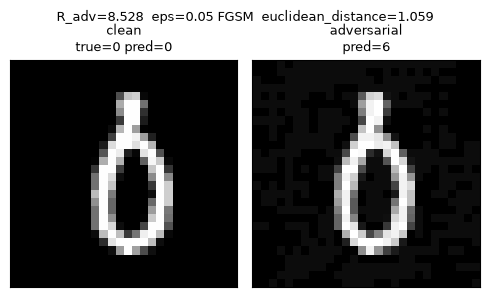

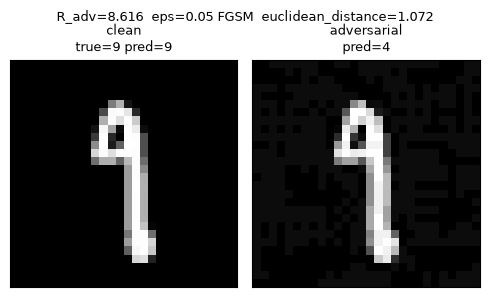

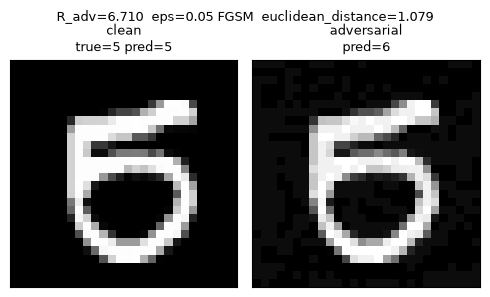

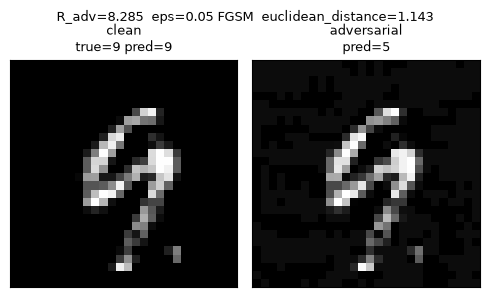

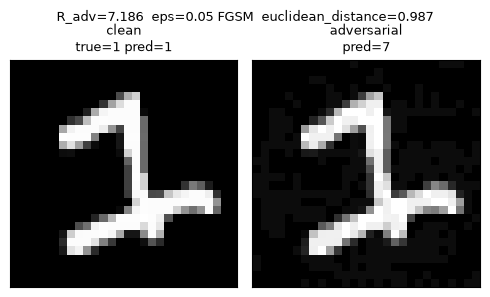

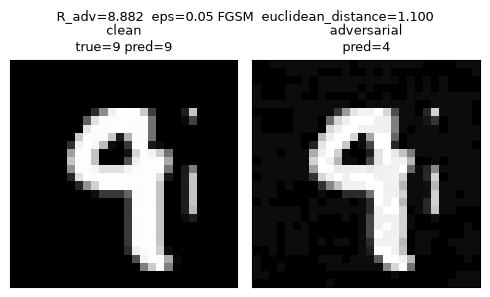

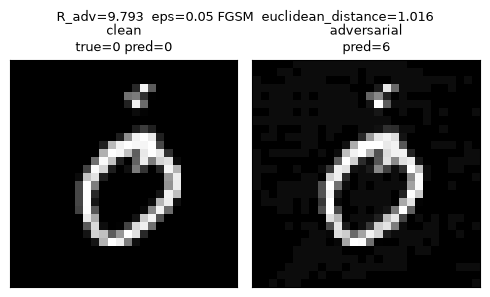

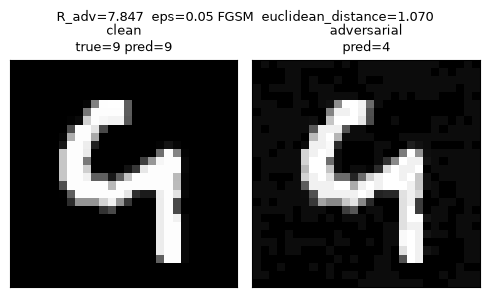

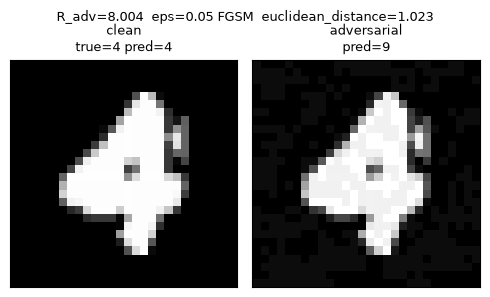

In [7]:
for i, example in enumerate(flagged_low_R_adv):
    print(f"--- example {i} (index={example['index']}) ---")
    print(f"R_adv={example['R_adv']:.4f}  pixel_distance (euclidean)={example['pixel_distance']:.4f}")
    print(f"logits_clean = {example['logits_clean'].detach().cpu().numpy().round(4)}")
    print(f"logits_adv   = {example['logits_adv'].detach().cpu().numpy().round(4)}")
    adv_plots.plot_example_pair(
        example, metric_name="Euclidean",
        save_path=run_experiment.RESULTS_DIR / f"strong_cnn_flagged_low_Radv_fgsm_eps0.05_{i}.png")


## Most and least sensitive attacked example

Across every `(epsilon, method)` case in the sweep above: the single attacked point that
achieved the LARGEST `R_adv` and the single one that achieved the SMALLEST `R_adv`, each
extended with `strong_cnn_head_layer_bound_check`'s feature-space-distance-vs-head-Lipschitz-
bound comparison for that specific example -- same idea as
`run_experiment.head_layer_bound_check` for SmallCNN, just using `strong_cnn_experiment`'s
externally-constructed extractor/head split.


In [8]:
most_sensitive, least_sensitive = most_and_least_sensitive_examples(wrapped_strong_cnn, sweep_results)
most_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive))
least_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive))

for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
    print(f"{label}: R_adv={example['R_adv']:.4f}  eps={example['epsilon']:g} {example['method']}  "
          f"true={example['y_true']}  pred_clean={example['pred_clean']}  pred_adv={example['pred_adv']}")
    print(f"    pixel_distance={example['pixel_distance']:.4f}  "
          f"feature_distance={example['feature_distance']:.4f}  "
          f"L_head_exact={example['L_head_exact']:.4f}  head_bound={example['head_bound']:.4f}  "
          f"actual={example['actual_logit_distance']:.4f}  "
          f"({example['head_bound_tightness']:.1%} of bound)")


most sensitive : R_adv=22.9244  eps=0.05 PGD  true=7  pred_clean=7  pred_adv=8
    pixel_distance=0.9683  feature_distance=12.4452  L_head_exact=2.5997  head_bound=32.3541  actual=22.1980  (68.6% of bound)
least sensitive: R_adv=1.9738  eps=0.25 FGSM  true=9  pred_clean=9  pred_adv=3
    pixel_distance=5.5864  feature_distance=9.5134  L_head_exact=2.5997  head_bound=24.7322  actual=11.0263  (44.6% of bound)


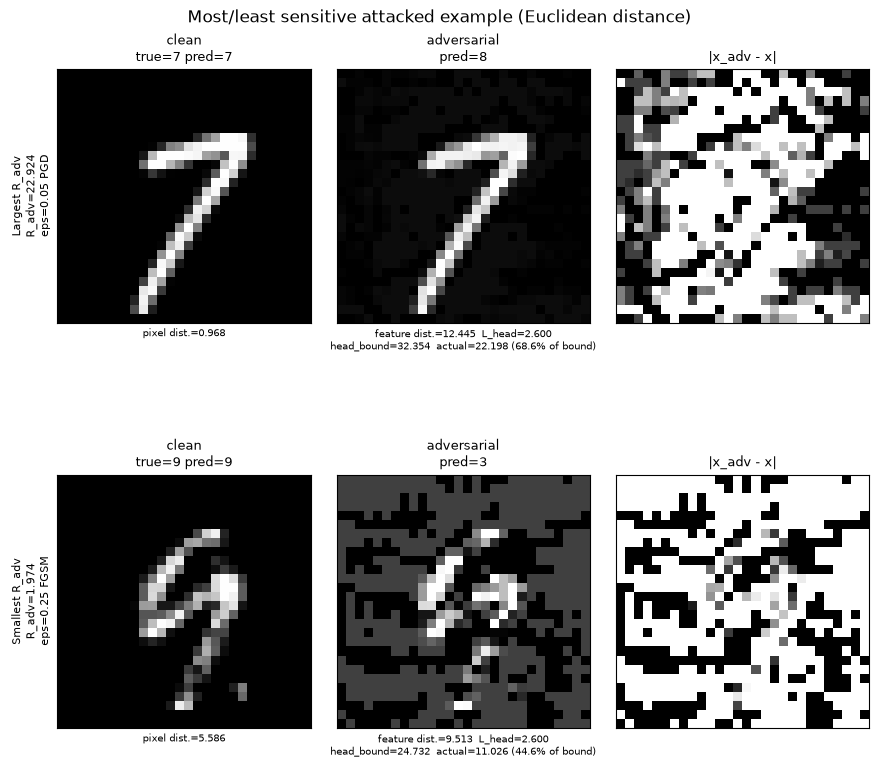

In [9]:
fig_extreme_eucl = adv_plots.plot_extreme_examples(
    most_sensitive, least_sensitive, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_euclidean.png")


# Repeating the Experiment with Mahalanobis Distance

Same construction as the SmallCNN notebook's own Euclidean-vs-Mahalanobis section: a
ridge-regularized Mahalanobis distance fit from MNIST's own pixel covariance
(`run_experiment.build_pixel_mahalanobis_distance_fn`, `epsilon=0.01`, the same established
choice used throughout this project -- see `mnist_lipschitz/README.md`'s "Epsilon selection"
section for why).


In [10]:
train = run_experiment.load_mnist(train=True)
mahalanobis_distance_fn = run_experiment.build_pixel_mahalanobis_distance_fn(train.x_flat)


## Baseline checkpoint (Mahalanobis)

`strong_cnn_experiment.main(distance_fn=mahalanobis_distance_fn)` reuses the SAME trained
checkpoint as the Euclidean section above (loaded from `results/strong_cnn_state_dict.pt`,
matching `seed=0` -- no retraining) and the SAME adversarial examples (attacks don't depend on
`distance_fn`, see `run_epsilon_sweep`'s own docstring) -- only how sensitivity is MEASURED
differs.


In [11]:
summary_df_mahalanobis, sweep_results_mahalanobis, _ = strong_cnn_experiment.main(
    distance_fn=mahalanobis_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict.pt (train_acc=0.9981  test_acc=0.9966)


  [distance_fn='<lambda>'] L_head_exact=2.1033  L_extractor_est=1.9008  L_full_est=2.9475  looseness_ratio=1.3564


filter_correctly_classified: kept 0.9965 of the pool (1993/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=1.8488  max_R_adv=2.7853  pct_misclassified=0.2600


  epsilon=0.05  PGD   mean_R_adv=2.6325  max_R_adv=4.0785  pct_misclassified=0.6780


...

  epsilon=0.15  PGD   mean_R_adv=1.6383  max_R_adv=2.4547  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=0.7253  max_R_adv=1.0268  pct_misclassified=0.8500


  epsilon=0.2  PGD   mean_R_adv=1.4449  max_R_adv=2.0829  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=0.6084  max_R_adv=0.8542  pct_misclassified=0.9240


  epsilon=0.25  PGD   mean_R_adv=1.3222  max_R_adv=1.8149  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    1.848762      1.853538   2.785297              0.260          2.947524       3.997957         0.944962                0.696680
    0.10   FGSM    1.208225      1.207779   1.755766              0.564          2.947524       3.997957         0.595675                0.439166
    0.15   FGSM    0.903237      0.898126   1.299958              0.764          2.947524       3.997957         0.441034                0.325156
    0.20   FGSM    0.725329      0.720410   1.026842              0.850          2.947524       3.997957         0.348374                0.256842
    0.25   FGSM    0.608355      0.599669   0.854214              0.924          2.947524       3.997957         0.289807                0.213663
    0.05    PGD    2.632469      2.58348

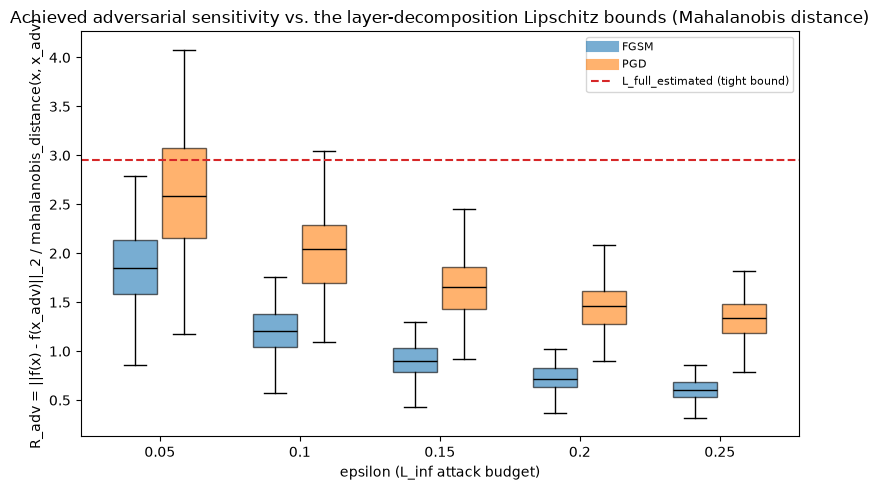

In [12]:
fig_R_adv_maha = adv_plots.plot_R_adv_distribution(
    sweep_results_mahalanobis, summary_df_mahalanobis["L_full_estimated"].iloc[0],
    summary_df_mahalanobis["product_bound"].iloc[0], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_mahalanobis.png")


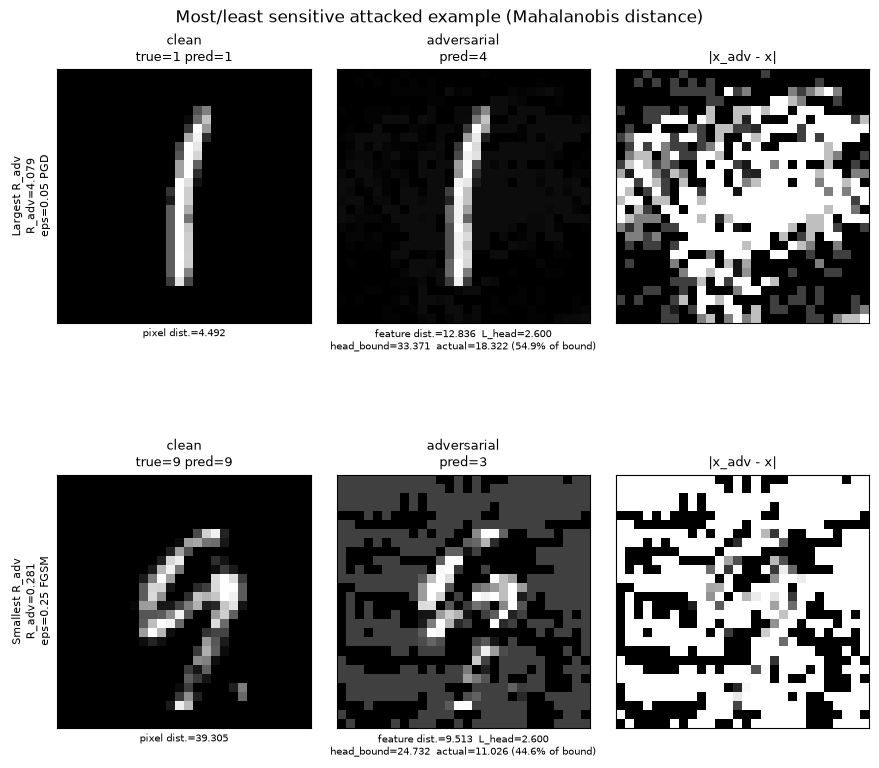

In [13]:
most_sensitive_maha, least_sensitive_maha = most_and_least_sensitive_examples(
    wrapped_strong_cnn, sweep_results_mahalanobis, distance_fn=mahalanobis_distance_fn)
most_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive_maha))
least_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive_maha))

fig_extreme_maha = adv_plots.plot_extreme_examples(
    most_sensitive_maha, least_sensitive_maha, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_mahalanobis.png")


## Comparison: Euclidean vs. Mahalanobis

Both metrics were run against the SAME checkpoint and the SAME adversarial examples throughout
(see the section intro above) -- so any difference below reflects only how "distance" is
measured, not a confound from different models or different attacks.


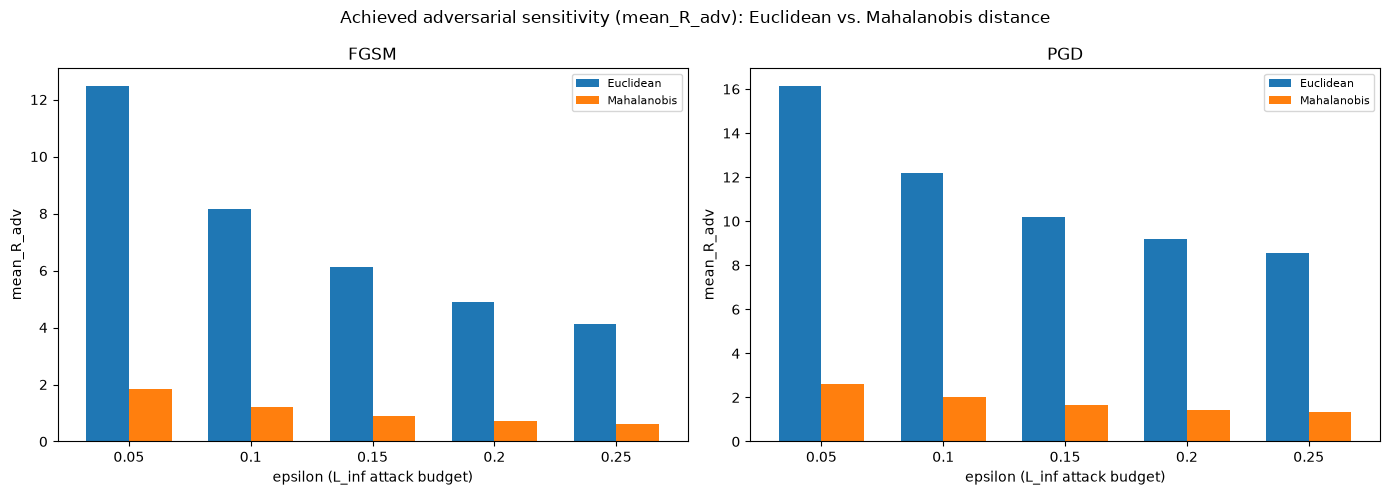

In [14]:
fig_cmp = adv_plots.plot_euclidean_vs_mahalanobis_R_adv(
    summary_df, summary_df_mahalanobis,
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_euclidean_vs_mahalanobis_R_adv.png")


## Summary and status

See the printed tables and plots above for the actual measured numbers (they vary run to run
with the random seed and aren't restated here to avoid this notebook silently going stale
against its own output -- re-run the cells above for the current numbers).

**Design decisions**:
- `strong_cnn_experiment.py` reuses `attacks.py`, `plots.py`, and every architecture-agnostic
  function in `run_experiment.py` (`run_epsilon_sweep`, `summarize_epsilon_sweep`,
  `most_and_least_sensitive_examples`, ...) UNCHANGED -- only the extractor/head split and the
  bound-computation/training driver are StrongCNN-specific.
- `model.eval()` discipline is enforced by RAISING, not silently fixed -- see
  `strong_cnn_experiment.py`'s module docstring.
- No CNN-width sweep or multi-seed pilot -- out of scope (see the Motivation cell above).

**Explicitly out of scope, not attempted**: any capacity/width sweep for StrongCNN (no width
parameter exists); a multi-seed confirmation sweep (`seed_sweep.py`'s pattern); Carlini-Wagner or
other attack methods (FGSM/PGD only, same as the SmallCNN notebook); adversarial training or any
other mitigation.


## Findings and observations (seed=0 run)

The "Summary and status" section above deliberately avoids restating numbers to stay from going
stale. This section is the exception: it records what a specific run (`seed=0`, `train_acc=0.9981`,
`test_acc=0.9966`, `n_query_points=1000`) actually showed, as a snapshot -- re-run and compare
rather than trusting these figures blind if the code has since changed.

### Baseline bounds

`L_head_exact=2.103` (identical between metrics, by construction -- confirmed directly: the head
maps extracted features, always Euclidean, to logits, always Euclidean; only the pixel-space side
is pluggable).

| Metric | `L_extractor_est` | `L_full_estimated` | `product_bound` | `looseness_ratio` |
|---|---|---|---|---|
| Euclidean | 4.295 | 6.148 | 9.034 | 1.47x |
| Mahalanobis | 1.901 | 2.948 | 3.998 | 1.36x |

`looseness_ratio` is far tighter than SmallCNN's baseline (16.4x under Euclidean) -- StrongCNN's
much deeper extractor (6 conv/BatchNorm layers + a 256-d FC layer, vs. SmallCNN's 2 conv layers)
apparently makes the per-layer submultiplicative bound a much closer approximation to the
network's actual end-to-end sensitivity, at least at this query-sample size.

### A much more severe tight-bound gap than SmallCNN ever showed

**Under Euclidean distance, `max_R_adv` exceeds `L_full_estimated` at 9 of the 10 epsilon/method
combinations tested** (`ratio_to_L_full` from 0.92x up to 3.73x; only `epsilon=0.25`/FGSM stays
under the bound) -- not the occasional, mild (~1.00-1.02x) graze SmallCNN's baseline showed.
`summarize_epsilon_sweep`'s sanity-check warning fires on all but that one row. This is still
consistent with `L_full_estimated` being a valid LOWER BOUND from a finite, RANDOMLY-sampled
query set (not a real violation of any mathematical guarantee) -- but the magnitude here suggests
something more specific: even with 1000 natural (non-adversarial) query points in 784-d pixel
space (up from an earlier 200-point run, which found `L_full_estimated=5.716` -- a ~7.6% tighter
bound at 5x the query points, nowhere near enough to close the gap), `pairwise_lipschitz`'s
exhaustive scoring over random pairs is still very unlikely to land anywhere near the sharp,
localized sensitivity directions PGD's targeted, iterative gradient search can find -- and
StrongCNN's higher capacity/depth plausibly has MORE such sharp directions than SmallCNN's
shallower network, making random-pair sampling a much weaker proxy for its true worst-case
sensitivity, largely independent of how many query points are drawn.

**Under Mahalanobis distance, the same gap is dramatically smaller, and the tight bound is not
even exceeded for most rows** (`ratio_to_L_full` ranges `0.29x-1.38x`, vs. Euclidean's
`0.92x-3.73x` at the same epsilons; the warning fires only for `epsilon=0.05`/PGD and
`epsilon=0.10`/PGD) -- the OPPOSITE pattern from the SmallCNN width sweep, where Mahalanobis
distance was found to WIDEN the gap between achieved sensitivity and both bounds, not narrow it
(see `notebook_adversarial_lipschitz.ipynb`'s own findings). Why the direction of this effect
flips between the two architectures is not established here -- worth investigating directly (e.g.
whether it's driven by StrongCNN's much larger `L_extractor_estimated` gap between metrics,
`4.295` vs. `1.901`, a ~2.3x difference vs. SmallCNN's comparatively smaller metric gap at its
default width).

### Most/least sensitive example (Euclidean)

The single largest-`R_adv` example (`R_adv=22.92`, `epsilon=0.05` PGD, true digit 7 flipped to
predicted 8) reaches only **68.6%** of the head layer's own exact Cauchy-Schwarz bound
(`actual_logit_distance / head_bound`) -- meaning even the most-effective real attack found here
doesn't max out the (always-tight, exact) head-layer bound; the "excess" over `L_full_estimated`
traces to the extractor/pixel-to-feature portion of the network being far more sensitive along
this PGD-found direction than the random query-point pairs happened to reveal, not to any part of
the pipeline being mismeasured.

## Status

**Confirmed working:** all 18 `tests/test_strong_cnn_experiment.py` tests pass, including the
composition-identity check (`strong_cnn_head_module(model)(strong_cnn_extractor_fn(model,x,y))
== model(x)` exactly), the eval-mode-matters checks (BatchNorm's train-mode batch-dependence
confirmed directly; every StrongCNN-specific function raises `ValueError` if called with
`model.training=True`), and the self-consistency parity check. This notebook executes end to end
with zero errors; total standalone wall-clock time for `main()`'s first (training) call was
~19.7 minutes on CPU (~18 min training StrongCNN's `STRONG_CNN_CONFIG` recipe -- 25 epochs, full
60k MNIST, augmentation -- plus ~100s for the bound comparison and full FGSM/PGD sweep at
`n_query_points=200`; re-running at `n_query_points=1000` adds a modest amount of extra time to
the bound-estimation step only, since `pairwise_lipschitz`'s pair sampling doesn't scale
quadratically with `max_pairs=None` capped); the notebook's own two `main()` calls both hit the
cached checkpoint and ran in a small fraction of the full training time.

**Explicitly out of scope, not attempted:** any CNN-capacity/width sweep for StrongCNN (its conv
channels are hardcoded, not a constructor parameter, unlike `SmallCNN`'s); a multi-seed
confirmation sweep (`seed_sweep.py`'s pattern, also `SmallCNN`-specific); Carlini-Wagner or other
attack methods (FGSM/PGD only); adversarial training or any other mitigation.

**Worth revisiting:**
- **Why the Euclidean-vs-Mahalanobis gap-width effect flips direction between StrongCNN and
  SmallCNN is not established** (see above) -- the single most interesting open question from
  this run.
- **`n_query_points` was raised from 200 to 1000 for the Lipschitz-bound estimate** and only
  modestly tightened `L_full_estimated` (Euclidean: `5.716 -> 6.148`; Mahalanobis:
  `2.508 -> 2.948`) while the achieved-vs-bound gap remained large -- consistent with the sharp,
  PGD-found sensitivity directions being intrinsically hard for random-pair sampling to hit,
  rather than a simple undersampling artifact fixable by more query points; not pushed further
  (e.g. 5000+ points) here.
- **This is a single-seed run** -- whether the ~1.4x `looseness_ratio` or the
  Euclidean/Mahalanobis gap-width reversal are stable across seeds is unknown.
